# Ensemble

We combine all the topic models to create an ensemble representation of the narrative structure.

In [1]:
local_lib = "../../local_lib"
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns; sns.set()
import sys; sys.path.append(local_lib)
from narrative_parser import NarrativeParser
from narrative_model import NarrativeModel

## Combine All

In [2]:
sources = "ajtzibab christenson colop christenson_ximenez ximenez".split()
text = {src:{'parser':None, 'model':None} for src in sources}
for src_id in sources:
    print(src_id)
    src_path = f"../{src_id}"
    doc_file = f"{src_path}/{src_id}-DOC.csv"
    doc_idx_file = f"{src_path}/{src_id}-DOC_idx.txt"
    doc_idx = open(doc_idx_file, "r").read().split(",")
    DOC = pd.read_csv(f"{src_path}/{src_id}-DOC.csv").set_index(doc_idx)
    parser = NarrativeParser(src_id, DOC)
    parser.run()
    model = NarrativeModel(src_id, parser.CHUNK, parser.TFIDF)
    model.compute_nmf()
    # model.plot_topics_over_time()
    text[src_id]['parser'] = parser
    text[src_id]['model'] = model


ajtzibab
christenson
colop
christenson_ximenez
ximenez


In [3]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# This is to align the topic model numbers
# The column lists were discovered by comparing topic glosses (see below)
def fix_cols(df):
    if src_id == 'ximenez':
        df = df[[0,1,3,2,4,5]]
    elif src_id == 'christenson_ximenez':
        df =  df[[0,1,3,2,5,4]]
    df.columns = [0,1,2,3,4,5]
    return df

# Combine all the topic models
theta_list = []
topic_list = []
for src_id in sources:
    theta = text[src_id]['model'].THETA
    theta.columns = [0,1,2,3,4,5] # Convert col names to ints
    theta = fix_cols(theta)
    theta_list.append(theta)
    topic = text[src_id]['model'].TOPIC
    topic = fix_cols(topic.T).T
    topic_list.append(topic)
THETA = pd.concat(theta_list, keys = sources).groupby('chunk_num', observed=False).mean()
TOPIC = pd.concat(topic_list, keys = sources)

# Compare topic glosses to see if topics align
TOPIC_gloss = TOPIC.gloss.unstack()
TOPIC_gloss.index.name = 'src_id'
TOPIC_gloss.columns.name = 'topic_id'
TOPIC_gloss


topic_id,0,1,2,3,4,5
src_id,,,,,,
ajtzibab,kame,tojil,ajpop,kaj,sipakna,kati't
christenson,xib'alb'a,b'alam,pop,b'it,sipakna,kati't
colop,kame,b'alam,ajaw,kaj,sipakna,kati't
christenson_ximenez,xibalba,balam,ahpop,cah,caquix,batz
ximenez,xibalba,balam,ahpop,cah,zipacna,catit


## Visualize Ensemble Topics over Time

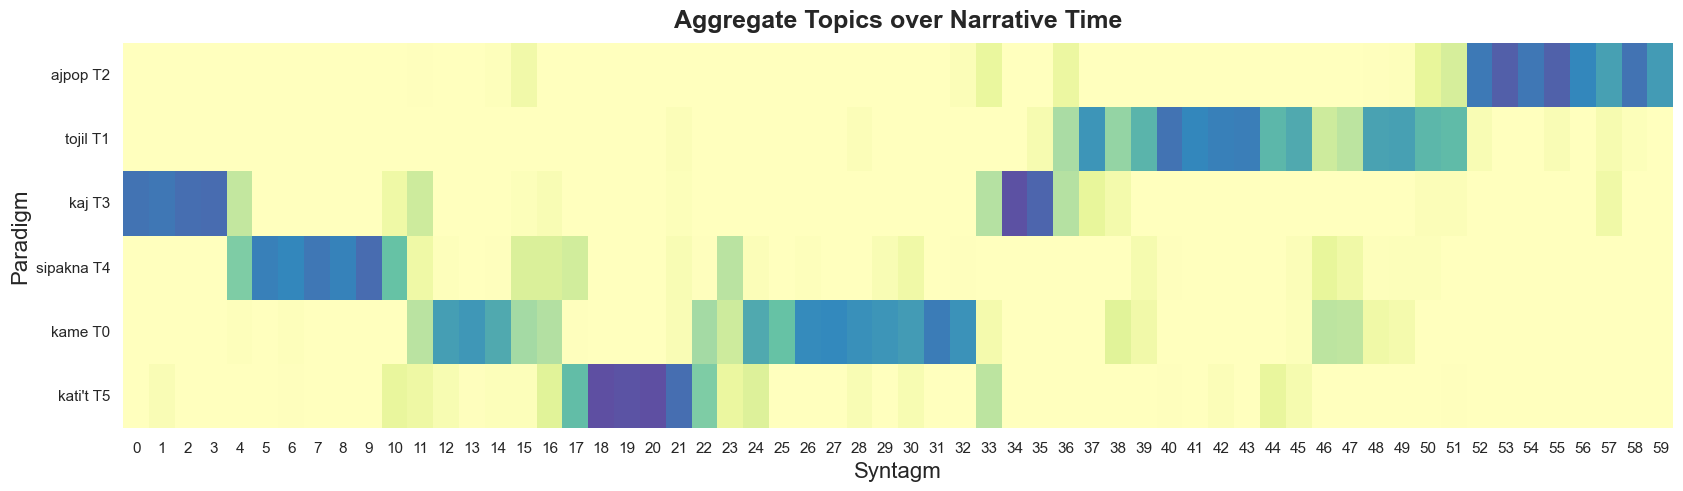

In [4]:
# Set the display order of the topics
new_order= [2,1,3,4,0,5]

# Replace topic numbers with glosses in the display
y_labels = TOPIC.loc['ajtzibab'].loc[new_order].label
fig, ax = plt.subplots(figsize=(20,5))
sns.heatmap(
    THETA.T.loc[new_order].set_index(y_labels), 
    cmap='Spectral', 
    center=0,
    cbar=None
)
plt.title(f"Aggregate Topics over Narrative Time", fontsize=18, fontweight='bold', y=1.02)
ax.set_xlabel("Chunk Number", fontsize=10)
ax.set_ylabel("Topic", fontsize=10)
plt.savefig(f"ensemble-topic-over-doc.svg", bbox_inches='tight')
plt.savefig(f"ensemble-topic-over-doc.png", bbox_inches='tight')
plt.xlabel("Syntagm", fontsize=16)
plt.ylabel("Paradigm", fontsize=16)
plt.show()

In [5]:
text['ajtzibab']['model'].TOPIC

,top_terms,gloss,label
topic_id,,,
0,"kame, xib'alb'a, naqi, ujolom, b'a",kame,kame T0
1,"tojil, b'alam, amaq', k'itze', majukutaj",tojil,tojil T1
2,"ajpop, ajaw, k'iche', ajawab', q'amja",ajpop,ajpop T2
3,"kaj, tz'aqol, b'itol, ulew, tz'aq",kaj,kaj T3
4,"sipakna, kaqix, k'ajolab', in, wuqub'",sipakna,sipakna T4
5,"kati't, chowen, b'atz', qati't, ati't",kati't,kati't T5


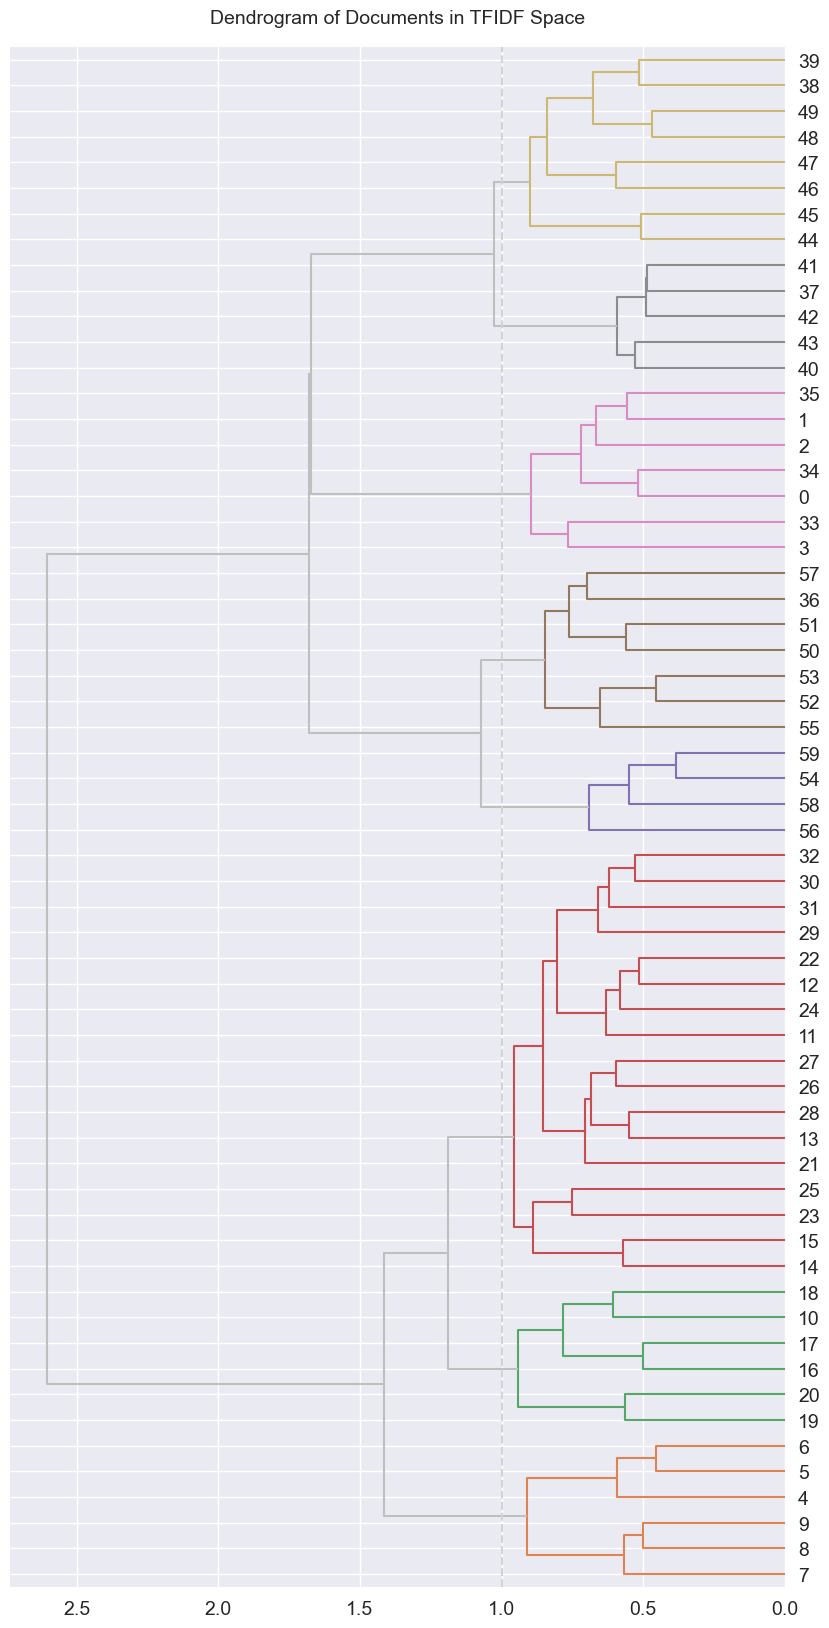

In [7]:
text['ajtzibab']['model'].compute_tfidf_sim()
text['ajtzibab']['model'].cluster()

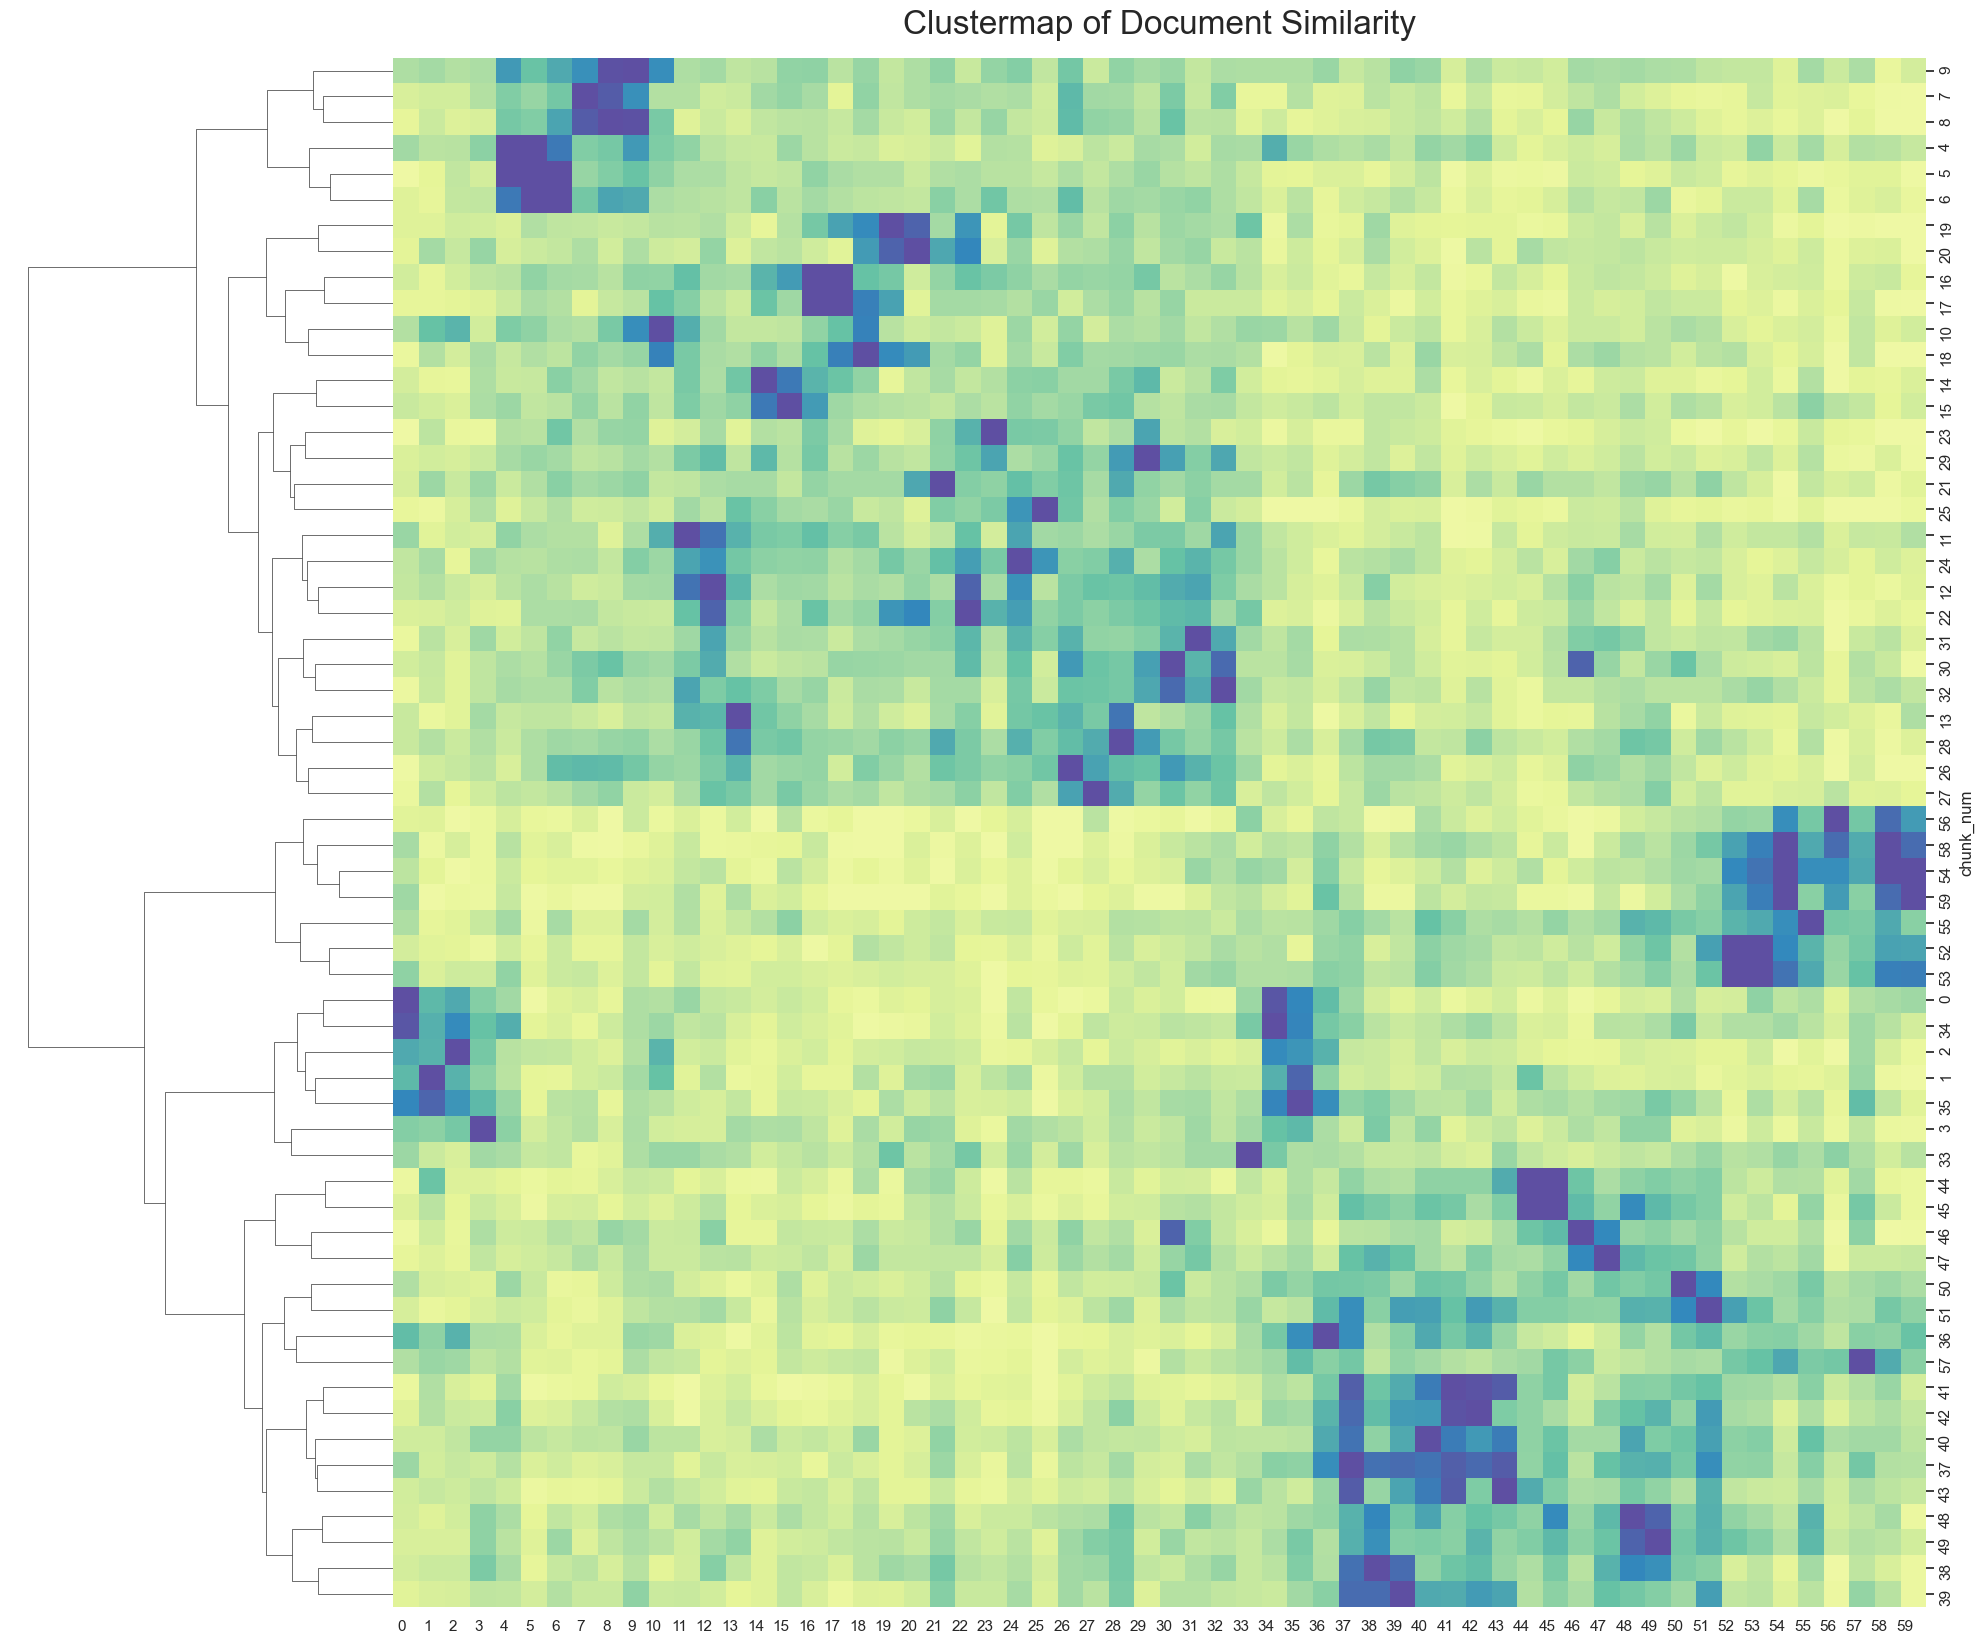

In [8]:
text['ajtzibab']['model'].plot_tfidf_clustermap()